<a href="https://colab.research.google.com/github/brunoss-on/scimlga2026/blob/main/lab01_TreinoRedeTirosRecFreq/treino_rede_recfreq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# Environment setup

import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    ENV = "colab"
    print("Running on Google Colab")
else:
    ENV = "local"
    print("Running locally")

Running on Google Colab


In [14]:
if ENV == "colab":

    print("Install dependencies")
    !pip install -q pytorch-msssim torchsummary

    # Library Imports
    import time
    from scipy import ndimage
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import random
    import seaborn as sns
    import sys
    import struct
    from scipy import interpolate

    import torch
    import torch.nn as nn
    from pytorch_msssim import ssim
    from torch.utils.data import Dataset, DataLoader
    from torch.optim import Adam

    from sklearn.model_selection import train_test_split
    from sklearn.feature_extraction.image import extract_patches_2d

    from torchsummary import summary

else:
    import time
    from scipy import ndimage
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import random
    import seaborn as sns
    import sys
    import struct
    from scipy import interpolate
    import torch
    import torch.nn as nn
    from pytorch_msssim import ssim
    from torch.utils.data import Dataset
    from sklearn.model_selection import train_test_split
    from torch.utils.data import DataLoader
    from torch.optim import Adam
    from sklearn.feature_extraction.image import extract_patches_2d
    from torchsummary import summary

Install dependencies


In [15]:
# Device Configuration: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [16]:
# Set up the workspace

# Clone the repository (only if it is not already present)
REPO_DIR = "/content/scimlga2026"
if not os.path.exists(REPO_DIR):
    print("Cloning the SciMLGA 2026 course repository from GitHub...")
    !git clone https://github.com/brunoss-on/scimlga2026.git {REPO_DIR}
    print("Repository successfully cloned!")
else:
    print("Repository already available. Skipping clone.")

print(os.getcwd())
print(os.listdir())

WORK_DIR = os.path.join(REPO_DIR, "lab01_TreinoRedeTirosRecFreq")
os.chdir(WORK_DIR)
print("Current directory:", os.getcwd())
print("Current contents:", os.listdir())

Repository already available. Skipping clone.
/content/scimlga2026/lab01_TreinoRedeTirosRecFreq
['model_l1_freq_val_loss.npy', 'model_l1_freq_train_loss.npy', 'model_mse.pth', 'model_mse_val_loss.npy', 'model_l1_freq.pth', 'treino_rede_recfreq.ipynb', 'model_mse_train_loss.npy']
Current directory: /content/scimlga2026/lab01_TreinoRedeTirosRecFreq
Current contents: ['model_l1_freq_val_loss.npy', 'model_l1_freq_train_loss.npy', 'model_mse.pth', 'model_mse_val_loss.npy', 'model_l1_freq.pth', 'treino_rede_recfreq.ipynb', 'model_mse_train_loss.npy']


In [17]:
# Load dataset
DATA_FILE = "filt_input_output.zip"
FILE_ID = "17UGfL09fS2dEMq-T7CD7p_lBhxkTKP05"

DATA_DIR = os.path.join(REPO_DIR,"resources_FiltragemTiros")

if not (
    os.path.exists(f"{DATA_DIR}/input.npy")
    and os.path.exists(f"{DATA_DIR}/output.npy")
):
    os.makedirs(DATA_DIR, exist_ok=True)
    !pip -q install gdown
    !gdown "https://drive.google.com/uc?id={FILE_ID}" -O "{DATA_DIR}/{DATA_FILE}"

    !unzip -q -o "{DATA_DIR}/{DATA_FILE}" -d "{DATA_DIR}"
else:
    print("Data already available.")

Data already available.


In [18]:
print("Current directory:", os.getcwd())
x_data= np.load('../resources_FiltragemTiros/input.npy')
y_data= np.load('../resources_FiltragemTiros/output.npy')
y_data=y_data[::4,:,:]/np.amax(abs(y_data))
x_data=x_data[::4,:,:]/np.amax(abs(x_data))

Current directory: /content/scimlga2026/lab01_TreinoRedeTirosRecFreq


In [19]:
img_train, x_test, mask_train, y_test = train_test_split(np.expand_dims(x_data,axis=1),np.expand_dims(y_data, axis=1),test_size=0.05,random_state=42)
#cria patches das imagens separadas para treino e validação
img_patches=[]
mask_patches=[]
patchshape=(64,64)
numpatches=5
for ind in range(img_train.shape[0]):
    for j in range(numpatches):
        i=np.random.randint(0,2000)
        patches_x = extract_patches_2d(img_train[ind,0,:,:], patchshape,max_patches=10, random_state=i)
        patches_y = extract_patches_2d(mask_train[ind,0,:,:],patchshape,max_patches=10, random_state=i)
        img_patches.append(patches_x)
        mask_patches.append(patches_y)
img_patches=np.expand_dims(np.concatenate(img_patches),axis=1)
mask_patches=np.expand_dims(np.concatenate(mask_patches),axis=1)
del img_train
del mask_train

In [20]:
BATCH = 32
x_train, x_val, y_train, y_val = train_test_split(img_patches,mask_patches,test_size=1/8,random_state=42)
class ImageDataset(Dataset):
    def __init__(self, images, masks):
        self.images = torch.tensor(images,dtype=torch.float32)
        self.masks = torch.tensor(masks,dtype=torch.float32)
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]
train_dataset = ImageDataset(x_train,y_train)

val_dataset = ImageDataset(x_val,y_val)
train_loader = DataLoader(train_dataset,batch_size=BATCH,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=BATCH,shuffle=False)

In [21]:
class Conv2dBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size=3,
                 batchnorm=False,
                 momentum=0.9):
        super().__init__()
        layers = []
        layers.append(
            nn.Conv2d(in_channels,out_channels,kernel_size=kernel_size,padding="same",bias=not batchnorm)
        )

        if batchnorm:
            layers.append(
                nn.BatchNorm2d(out_channels,momentum=1 - momentum)
            )

        layers.append(nn.ReLU(inplace=True))
        layers.append(
            nn.Conv2d(out_channels,out_channels,kernel_size=kernel_size,padding="same",bias=not batchnorm)
        )
        if batchnorm:
            layers.append(
                nn.BatchNorm2d(out_channels,momentum=0.1)
            )

        layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [22]:
class UNet(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.ConvTranspose2d(n_filters * 16,n_filters * 16,kernel_size=3,stride=2, padding=1,output_padding=1)

        self.up7 = nn.ConvTranspose2d(n_filters * 8,n_filters * 8,kernel_size=3,stride=2,padding=1,output_padding=1)

        self.up8 = nn.ConvTranspose2d(n_filters * 4,n_filters * 4,kernel_size=3,stride=2,padding=1,output_padding=1)

        self.up9 = nn.ConvTranspose2d(n_filters * 2,n_filters*2,kernel_size=3,stride=2,padding=1,output_padding=1)

        self.c6 = Conv2dBlock(n_filters * 16+n_filters * 8,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8+n_filters * 4,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4+n_filters * 2,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2+1,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment) #modificado para passagem da entrada

        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, x], dim=1)#passagem da entrada para os blocos finais
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return self.out(c9)

In [23]:
class UNetUp(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up7 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up8 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up9 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.c6 = Conv2dBlock(n_filters * 16+n_filters * 8,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8+n_filters * 4,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4+n_filters * 2,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2+1,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)
        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, x], dim=1)#passagem da entrada para os blocos finais
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return self.out(c9)

In [24]:
class FreqLoss(torch.nn.Module):
    def __init__(self,patch_size):
        super().__init__()
        self.patch_size=patch_size

    def forward(self, pred, label):

        pred_sp  = torch.fft.rfft(torch.nn.functional.pad(pred,(0,0,1024-self.patch_size[0],0), "constant", 0),axis=2)
        label_sp = torch.fft.rfft(torch.nn.functional.pad(label,(0,0,1024-self.patch_size[0],0), "constant", 0),axis=2)
        return torch.mean(torch.abs(torch.abs(pred_sp)-torch.abs(label_sp)))

In [25]:
EPOCAS=100
BATCH = 32
PATIENCE = 15
model = UNet(in_channels=1, n_filters=16,dropout=0.2,moment=0.2,batchnorm=False)
model = model.to(device)
summary(model,input_size=(1, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             416
              ReLU-2           [-1, 16, 64, 64]               0
            Conv2d-3           [-1, 16, 64, 64]           6,416
              ReLU-4           [-1, 16, 64, 64]               0
       Conv2dBlock-5           [-1, 16, 64, 64]               0
         MaxPool2d-6           [-1, 16, 32, 32]               0
         Dropout2d-7           [-1, 16, 32, 32]               0
            Conv2d-8           [-1, 32, 32, 32]          12,832
              ReLU-9           [-1, 32, 32, 32]               0
           Conv2d-10           [-1, 32, 32, 32]          25,632
             ReLU-11           [-1, 32, 32, 32]               0
      Conv2dBlock-12           [-1, 32, 32, 32]               0
        MaxPool2d-13           [-1, 32, 16, 16]               0
        Dropout2d-14           [-1, 32,

In [26]:
criterion = nn.MSELoss()
modelpath='model_mse'
#criterion1 = nn.L1Loss()
#criterion2 = AmpLoss(patchshape)
optimizer = Adam(model.parameters(),lr=1e-4,weight_decay=2e-4)

best_val_loss = float("inf")
counter = 0
train_losses = []
val_losses = []
train_maes = []
val_maes = []
for epoch in range(EPOCAS):
    # ======================
    # TREINO
    # ======================
    model.train()
    running_loss = 0.0
    running_mae = 0.0
    for images, targets in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(images)
 #       loss = criterion1(outputs, targets)+0.01*criterion2(outputs, targets)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        mae = torch.mean(torch.abs(outputs - targets))
        running_loss += loss.item()
        running_mae += mae.item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_mae = running_mae / len(train_loader)
    # ======================
    # VALIDAÇÃO
    # ======================
    model.eval()
    running_val_loss = 0.0
    running_val_mae = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            #loss = criterion1(outputs, targets)+0.01*criterion2(outputs, targets)
            loss = criterion(outputs, targets)
            mae = torch.mean(torch.abs(outputs - targets))
            running_val_loss += loss.item()
            running_val_mae += mae.item()
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_mae = running_val_mae / len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_maes.append(epoch_train_mae)
    val_maes.append(epoch_val_mae)

    print(
        f"Epoch [{epoch+1}/{EPOCAS}] "
        f"loss={epoch_train_loss:.4f} "
        f"mae={epoch_train_mae:.4f} "
        f"val_loss={epoch_val_loss:.4f} "
        f"val_mae={epoch_val_mae:.4f}"
    )

    # ======================
    # MODEL CHECKPOINT
    # ======================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),modelpath+'.pth')
        print(f"Val loss melhorou para {best_val_loss:.6f}. "f"Salvando modelo.")
        counter = 0
    else:
        counter += 1

        print(f"Val loss não melhorou. "f"Patience {counter}/{PATIENCE}")

        # ======================
        # EARLY STOPPING
        # ======================
        if counter >= PATIENCE:

            print("Early stopping!")
            break
np.save(modelpath+"_val_loss.npy", val_losses)
np.save(modelpath+"_train_loss.npy", train_losses)

Epoch [1/100] loss=0.0181 mae=0.1104 val_loss=0.0025 val_mae=0.0310
Val loss melhorou para 0.002493. Salvando modelo.
Epoch [2/100] loss=0.0027 mae=0.0362 val_loss=0.0014 val_mae=0.0210
Val loss melhorou para 0.001387. Salvando modelo.
Epoch [3/100] loss=0.0015 mae=0.0255 val_loss=0.0008 val_mae=0.0146
Val loss melhorou para 0.000772. Salvando modelo.
Epoch [4/100] loss=0.0010 mae=0.0202 val_loss=0.0006 val_mae=0.0150
Val loss melhorou para 0.000572. Salvando modelo.
Epoch [5/100] loss=0.0007 mae=0.0176 val_loss=0.0004 val_mae=0.0115
Val loss melhorou para 0.000404. Salvando modelo.
Epoch [6/100] loss=0.0006 mae=0.0161 val_loss=0.0004 val_mae=0.0123
Val loss melhorou para 0.000386. Salvando modelo.
Epoch [7/100] loss=0.0006 mae=0.0146 val_loss=0.0004 val_mae=0.0138
Val loss não melhorou. Patience 1/15
Epoch [8/100] loss=0.0005 mae=0.0139 val_loss=0.0004 val_mae=0.0156
Val loss não melhorou. Patience 2/15
Epoch [9/100] loss=0.0005 mae=0.0132 val_loss=0.0004 val_mae=0.0142
Val loss não m

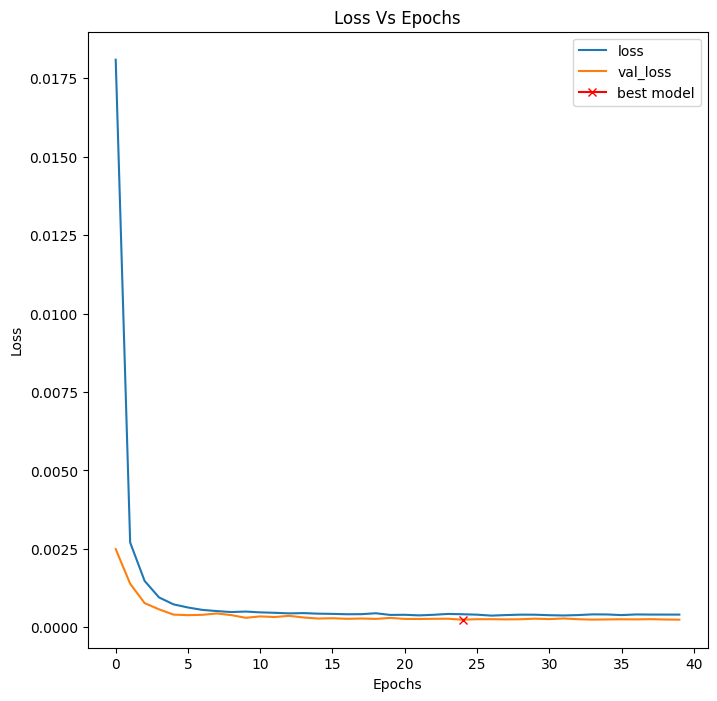

In [27]:
plt.figure(figsize=(8,8))
plt.title("Loss Vs Epochs")
plt.plot(train_losses, label="loss")
plt.plot(val_losses, label="val_loss")
plt.plot( np.argmin(val_losses), np.min(val_losses), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

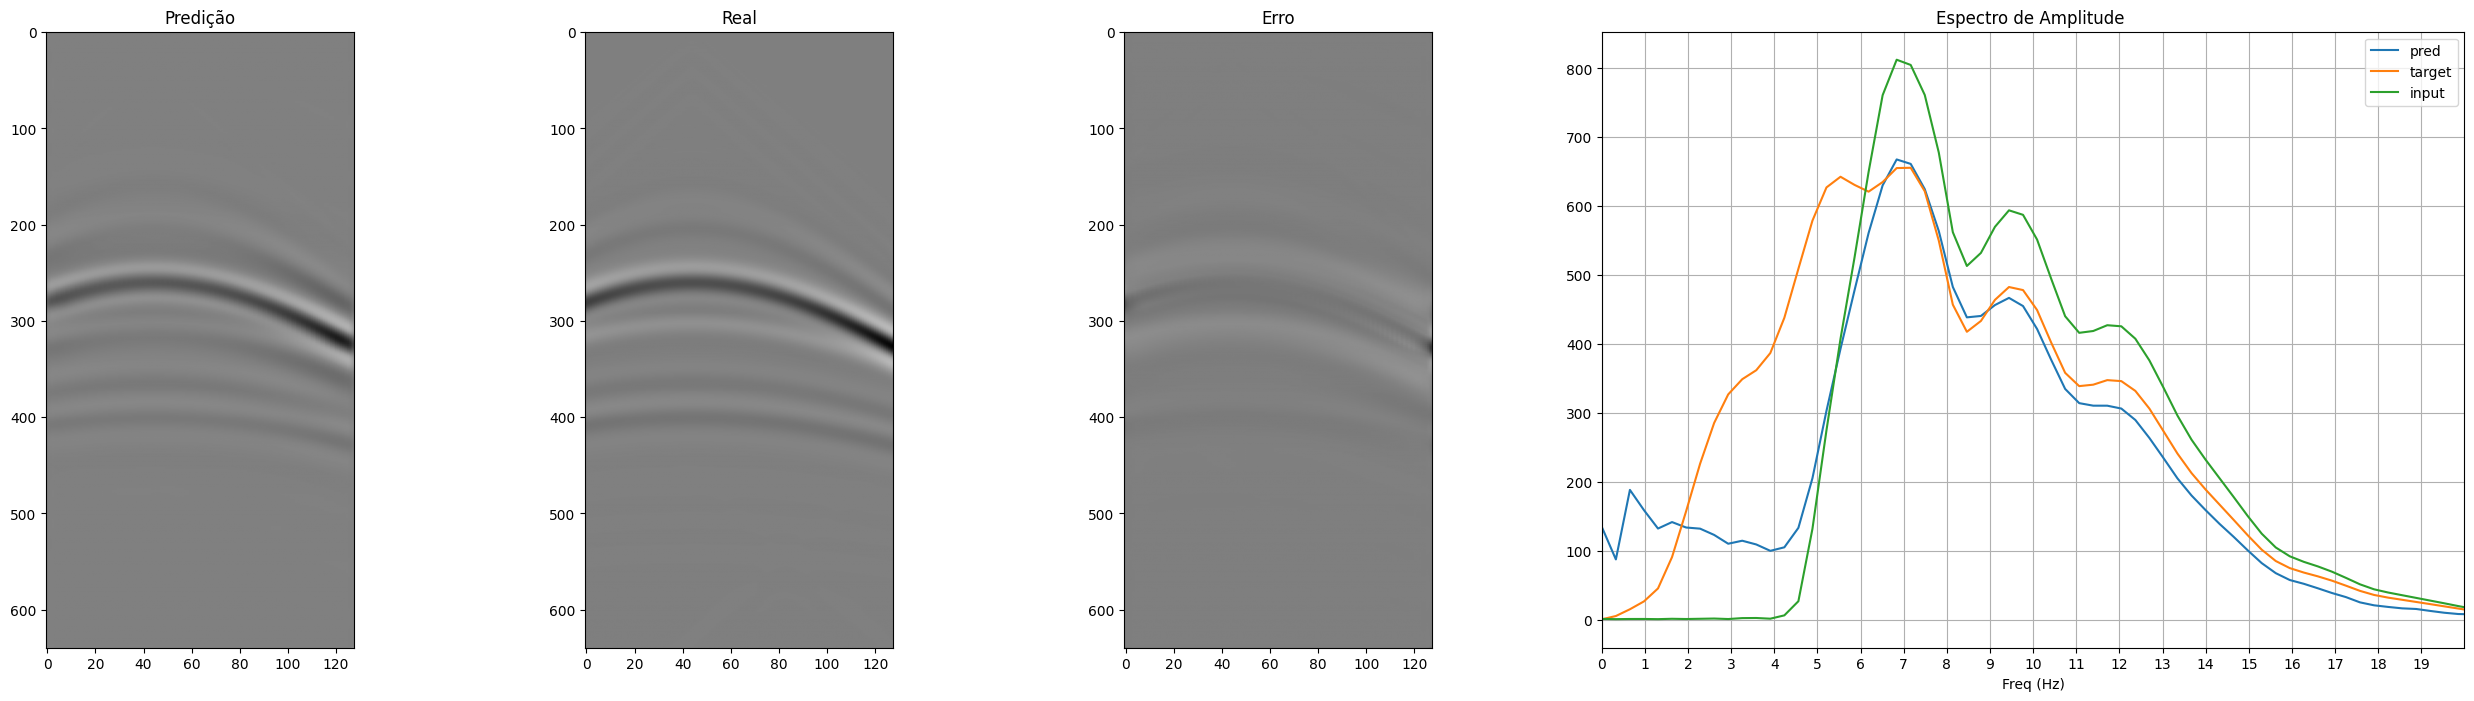

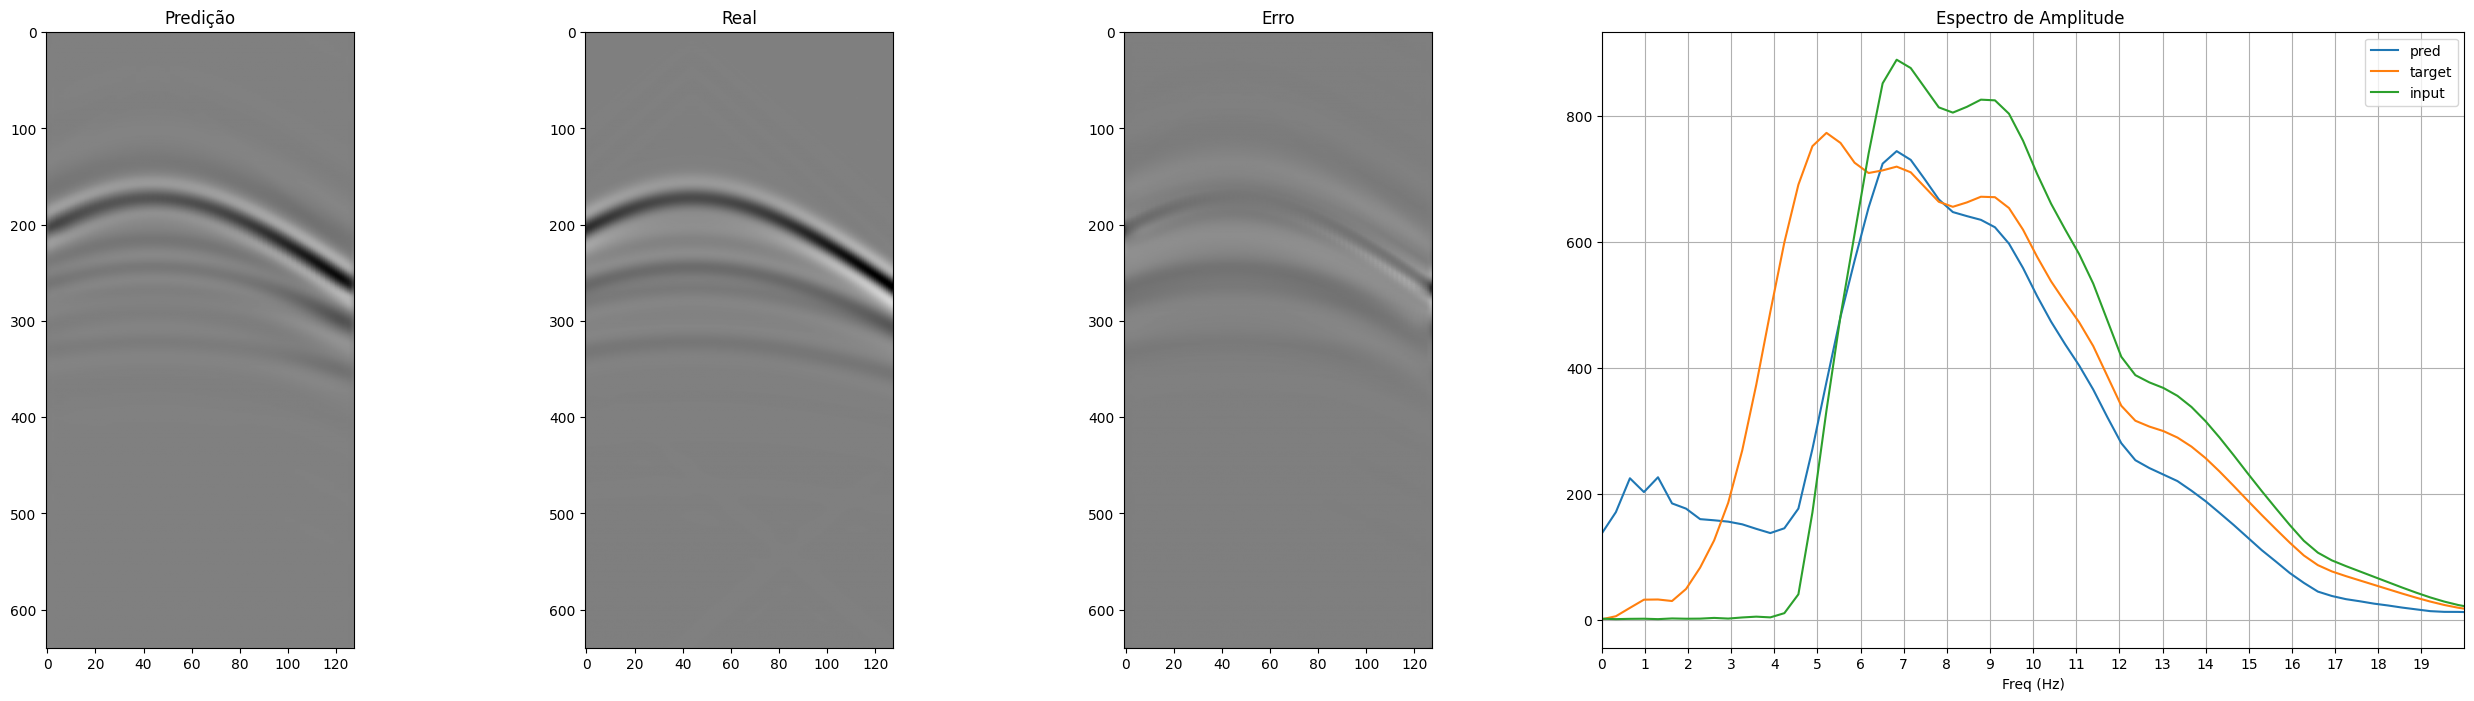

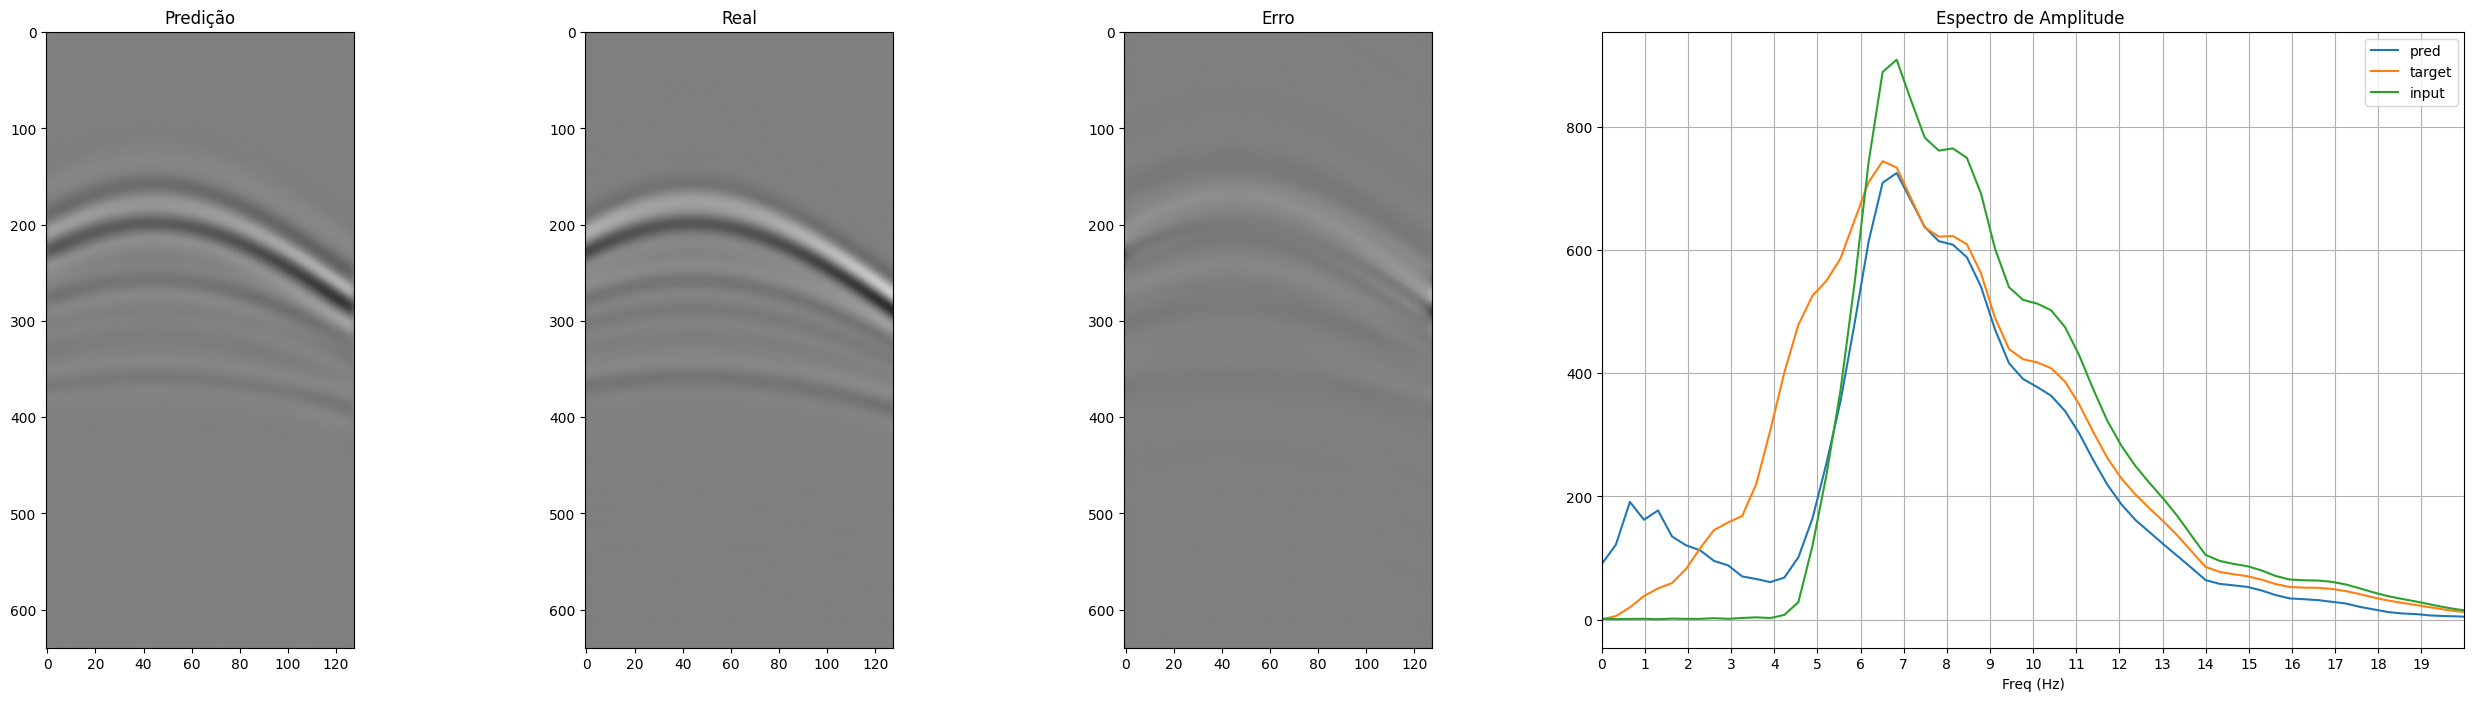

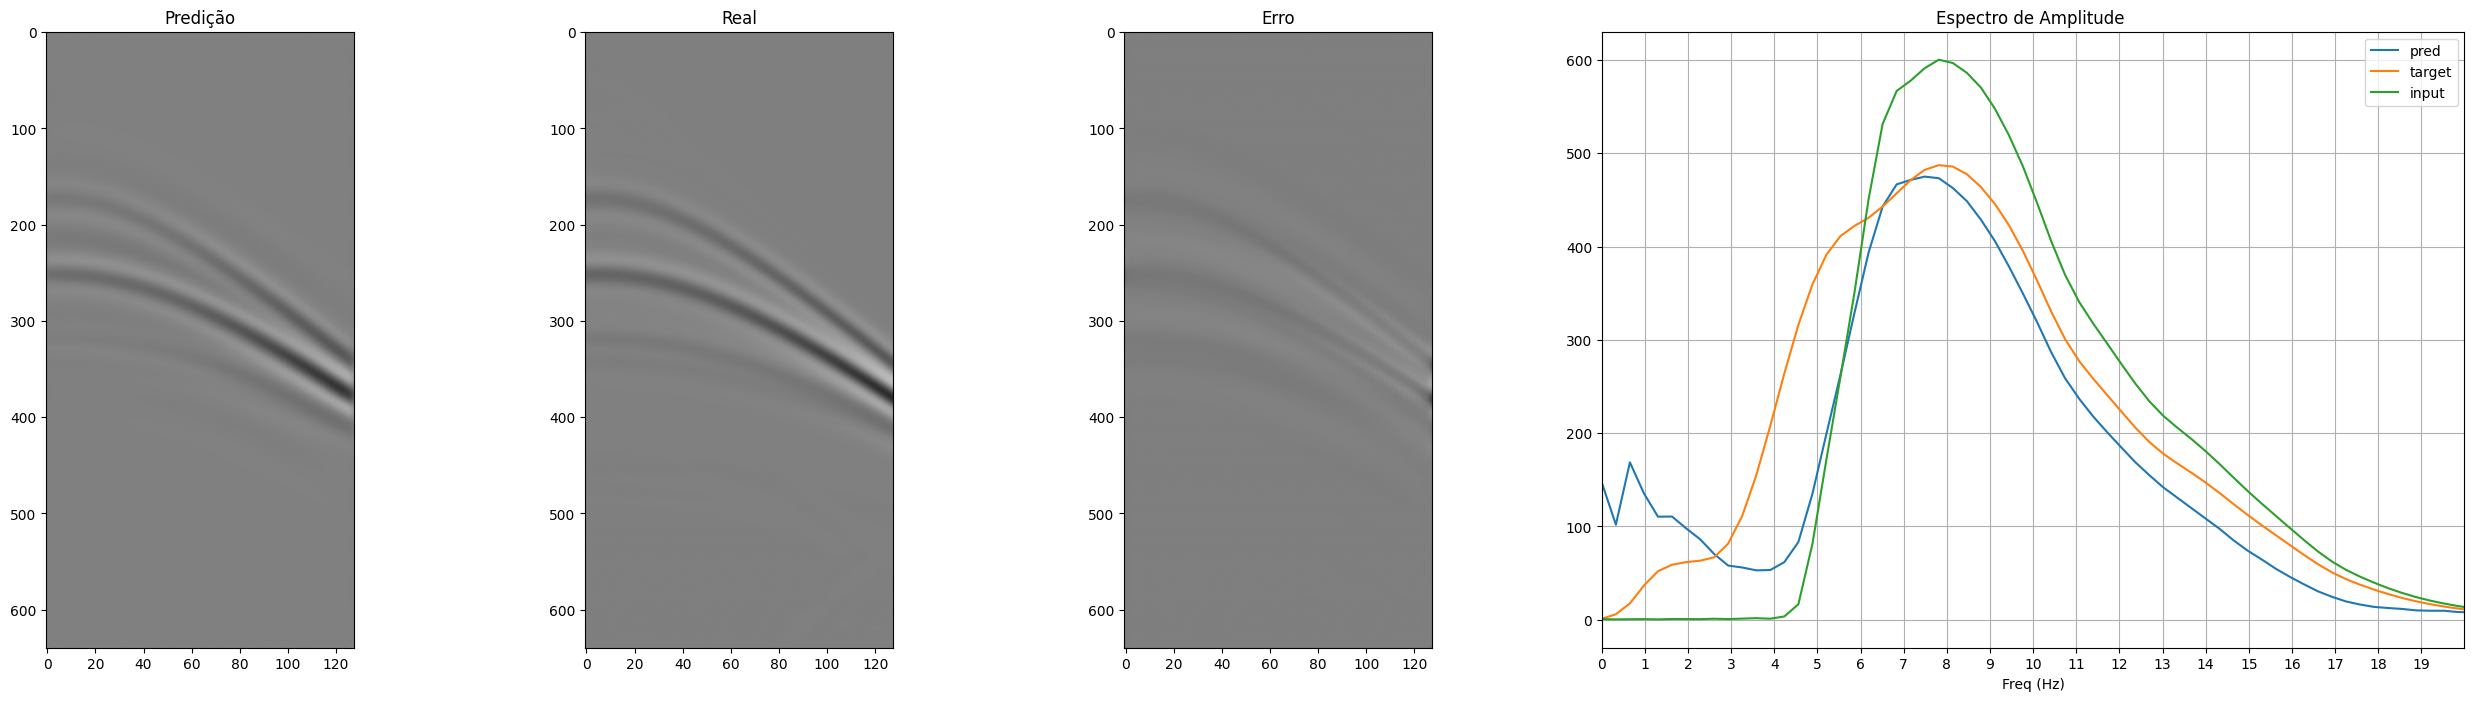

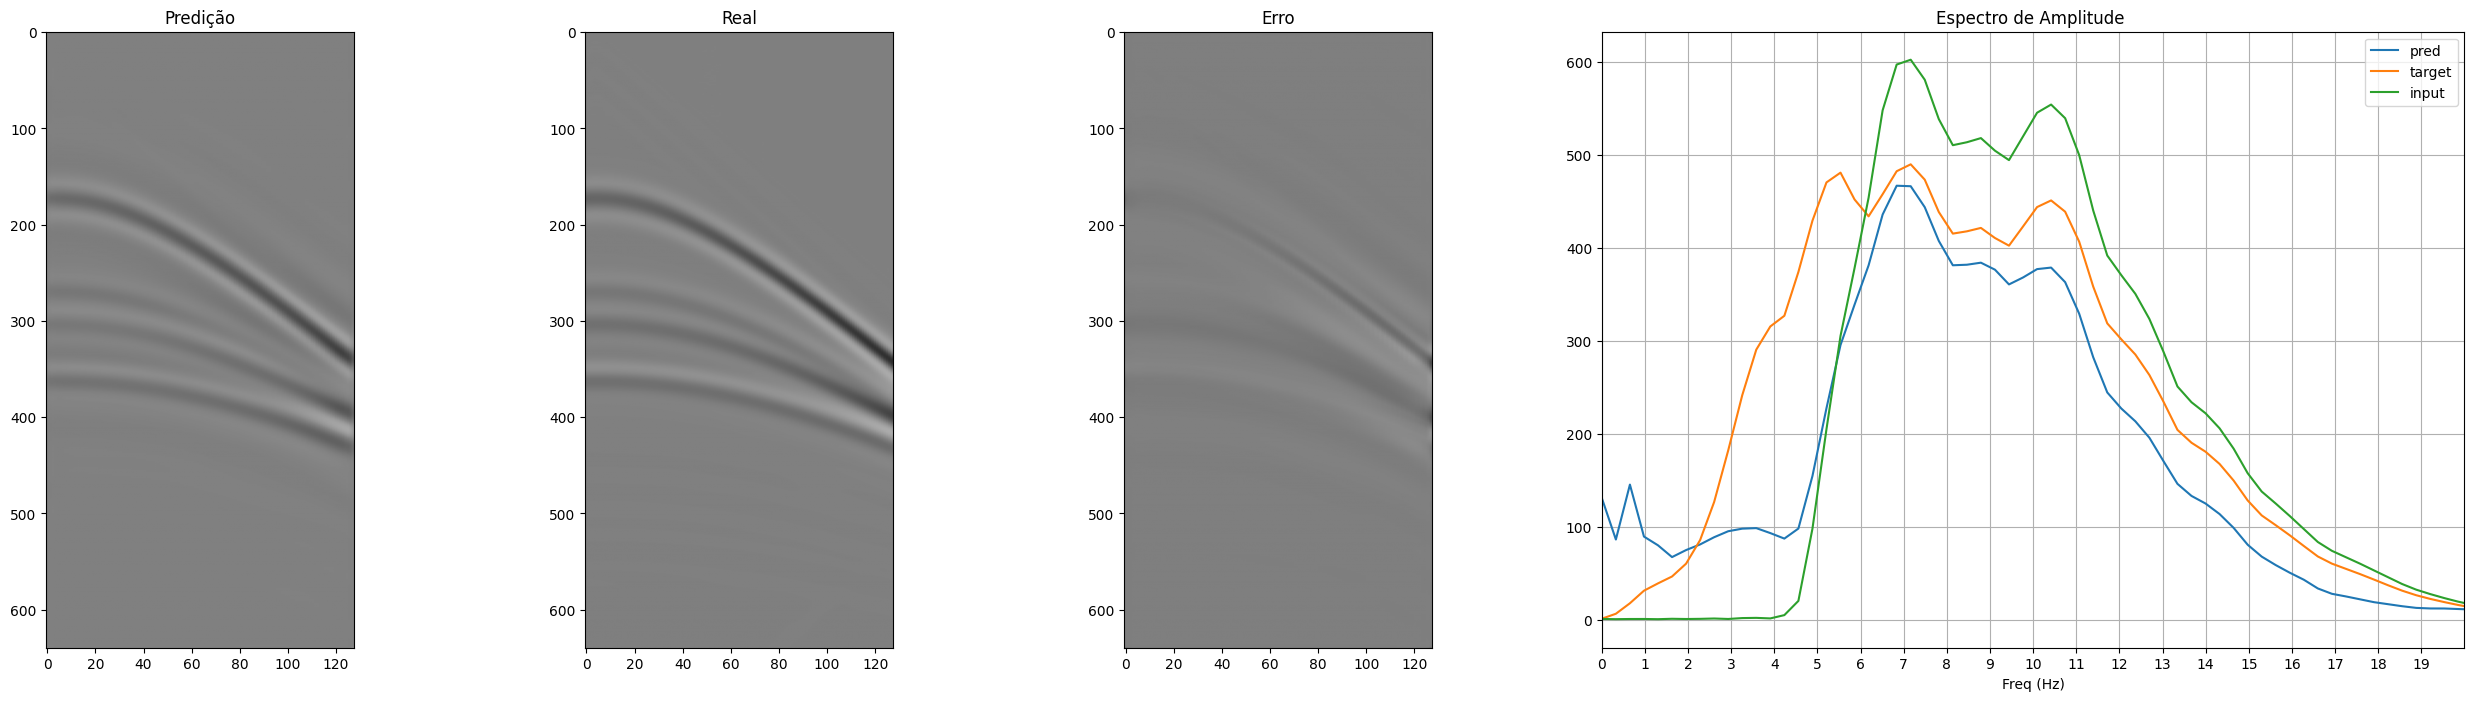

In [28]:
model.load_state_dict(torch.load(modelpath+'.pth'))
model.eval()
aspect=0.4
scale=0.5
pred = model(torch.tensor(x_test, dtype=torch.float32,device=device))
pred_cpu=pred.detach().cpu().numpy()
dt = 0.0030
freq = torch.fft.rfftfreq(1024, dt)
for n_image in range(len(x_test)):
    fig = plt.figure(figsize=(32,8))
    gs = fig.add_gridspec(1, 4,width_ratios=[1, 1, 1, 2])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[0, 3])
    DATA1 = torch.sum(torch.abs(torch.fft.rfft(torch.tensor(pred_cpu[n_image,0,:,:]), 1024,dim=0)),dim=1)
    DATA2 = torch.sum(torch.abs(torch.fft.rfft(torch.tensor(y_test[n_image,0,:,:]), 1024,dim=0)),dim=1)
    DATA3 = torch.sum(torch.abs(torch.fft.rfft(torch.tensor(x_test[n_image,0,:,:]), 1024,dim=0)),dim=1)

    ax1.imshow(pred_cpu[n_image,0,:,:],aspect=aspect,cmap="gray",vmin=-scale,vmax=scale)
    ax1.set_title('Predição')
    ax2.imshow(y_test[n_image,0,:,:],aspect=aspect,cmap="gray",vmin=-scale,vmax=scale)
    ax2.set_title('Real')
    ax3.imshow(y_test[n_image,0,:,:]-pred_cpu[n_image,0,:,:],aspect=aspect, cmap="gray",vmin=-scale,vmax=scale)
    ax3.set_title('Erro')
    ax4.plot(freq, DATA1, label='pred')
    ax4.plot(freq, DATA2, label='target')
    ax4.plot(freq, DATA3, label='input')
    ax4.grid()
    ax4.set_xlim(0,20)
    ax4.set_xlabel('Freq (Hz)')
    ax4.set_xticks(range(0, 20, 1))
    ax4.set_title('Espectro de Amplitude ')
    ax4.legend()
    fig = plt.gcf()
    plt.show()

In [29]:
model = UNet(in_channels=1, n_filters=16,dropout=0.2,moment=0.2,batchnorm=False)
model = model.to(device)
modelpath='model_l1_freq'
criterion1 = nn.L1Loss()
criterion2 = FreqLoss(patchshape)
optimizer = Adam(model.parameters(),lr=1e-4,weight_decay=2e-4)

best_val_loss = float("inf")
counter = 0
train_losses = []
val_losses = []
train_maes = []
val_maes = []
for epoch in range(EPOCAS):
    # ======================
    # TREINO
    # ======================
    model.train()
    running_loss = 0.0
    running_mae = 0.0
    for images, targets in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion1(outputs, targets)+criterion2(outputs, targets)
        loss.backward()
        optimizer.step()
        mae = torch.mean(torch.abs(outputs - targets))
        running_loss += loss.item()
        running_mae += mae.item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_mae = running_mae / len(train_loader)
    # ======================
    # VALIDAÇÃO
    # ======================
    model.eval()
    running_val_loss = 0.0
    running_val_mae = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion1(outputs, targets)+criterion2(outputs, targets)
            mae = torch.mean(torch.abs(outputs - targets))
            running_val_loss += loss.item()
            running_val_mae += mae.item()
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_mae = running_val_mae / len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_maes.append(epoch_train_mae)
    val_maes.append(epoch_val_mae)

    print(
        f"Epoch [{epoch+1}/{EPOCAS}] "
        f"loss={epoch_train_loss:.4f} "
        f"mae={epoch_train_mae:.4f} "
        f"val_loss={epoch_val_loss:.4f} "
        f"val_mae={epoch_val_mae:.4f}"
    )

    # ======================
    # MODEL CHECKPOINT
    # ======================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),modelpath+'.pth')
        print(f"Val loss melhorou para {best_val_loss:.6f}. "f"Salvando modelo.")
        counter = 0
    else:
        counter += 1

        print(f"Val loss não melhorou. "f"Patience {counter}/{PATIENCE}")

        # ======================
        # EARLY STOPPING
        # ======================
        if counter >= PATIENCE:

            print("Early stopping!")
            break
np.save(modelpath+"_val_loss.npy", val_losses)
np.save(modelpath+"_train_loss.npy", train_losses)

Epoch [1/100] loss=0.2258 mae=0.0554 val_loss=0.1043 val_mae=0.0175
Val loss melhorou para 0.104302. Salvando modelo.
Epoch [2/100] loss=0.0837 mae=0.0170 val_loss=0.0515 val_mae=0.0116
Val loss melhorou para 0.051517. Salvando modelo.
Epoch [3/100] loss=0.0540 mae=0.0130 val_loss=0.0383 val_mae=0.0091
Val loss melhorou para 0.038252. Salvando modelo.
Epoch [4/100] loss=0.0464 mae=0.0112 val_loss=0.0352 val_mae=0.0086
Val loss melhorou para 0.035174. Salvando modelo.
Epoch [5/100] loss=0.0423 mae=0.0102 val_loss=0.0354 val_mae=0.0085
Val loss não melhorou. Patience 1/15
Epoch [6/100] loss=0.0394 mae=0.0094 val_loss=0.0301 val_mae=0.0070
Val loss melhorou para 0.030078. Salvando modelo.
Epoch [7/100] loss=0.0369 mae=0.0087 val_loss=0.0294 val_mae=0.0069
Val loss melhorou para 0.029397. Salvando modelo.
Epoch [8/100] loss=0.0342 mae=0.0080 val_loss=0.0260 val_mae=0.0062
Val loss melhorou para 0.026022. Salvando modelo.
Epoch [9/100] loss=0.0321 mae=0.0075 val_loss=0.0258 val_mae=0.0062
V

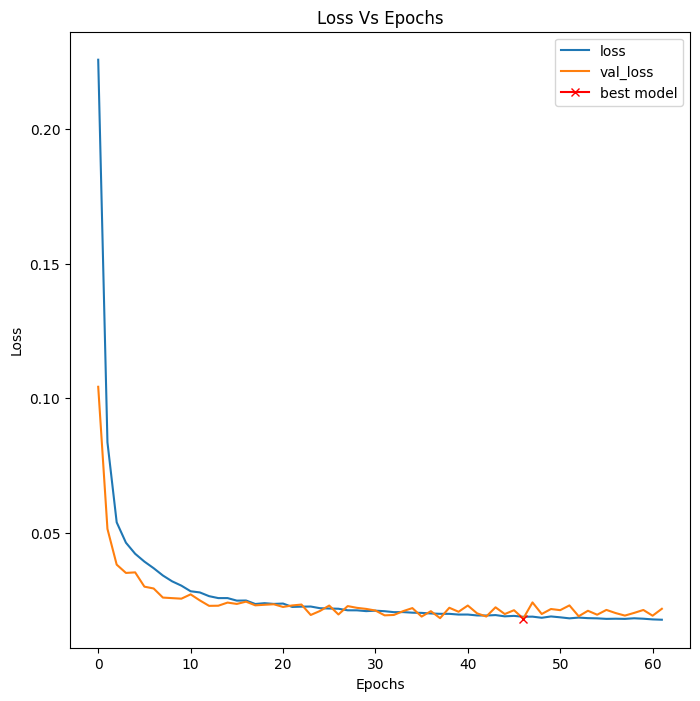

In [30]:
plt.figure(figsize=(8,8))
plt.title("Loss Vs Epochs")
plt.plot(train_losses, label="loss")
plt.plot(val_losses, label="val_loss")
plt.plot( np.argmin(val_losses), np.min(val_losses), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

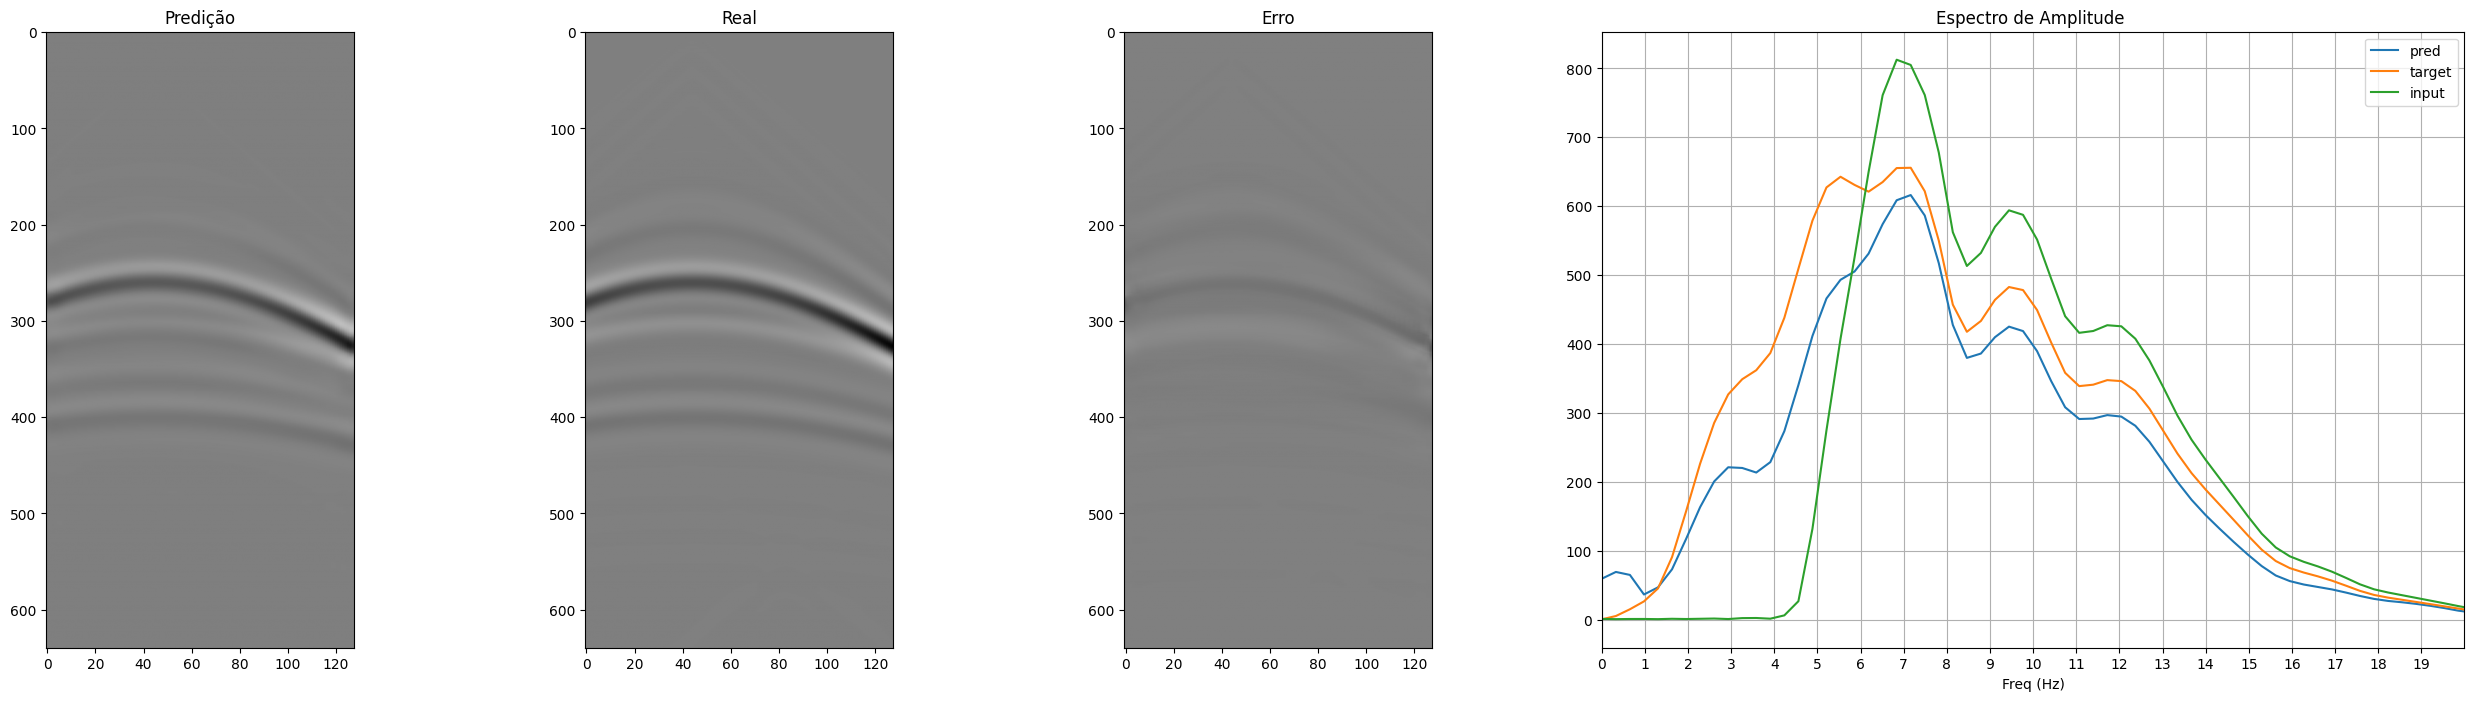

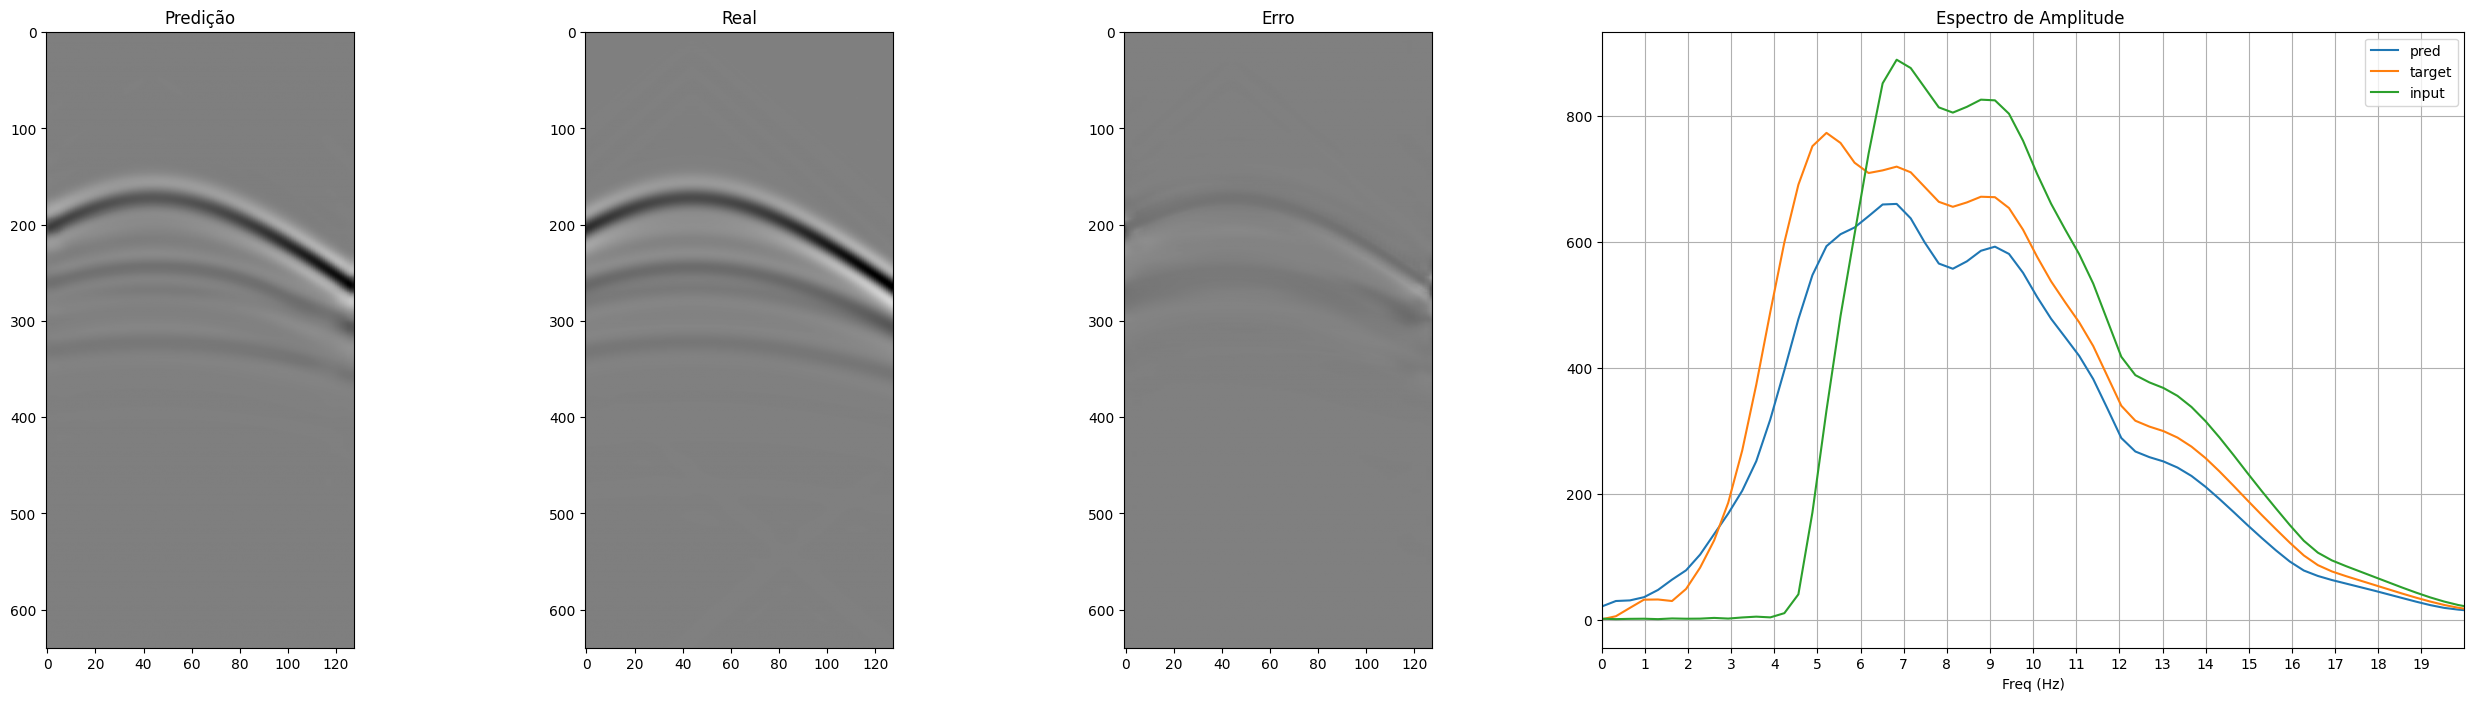

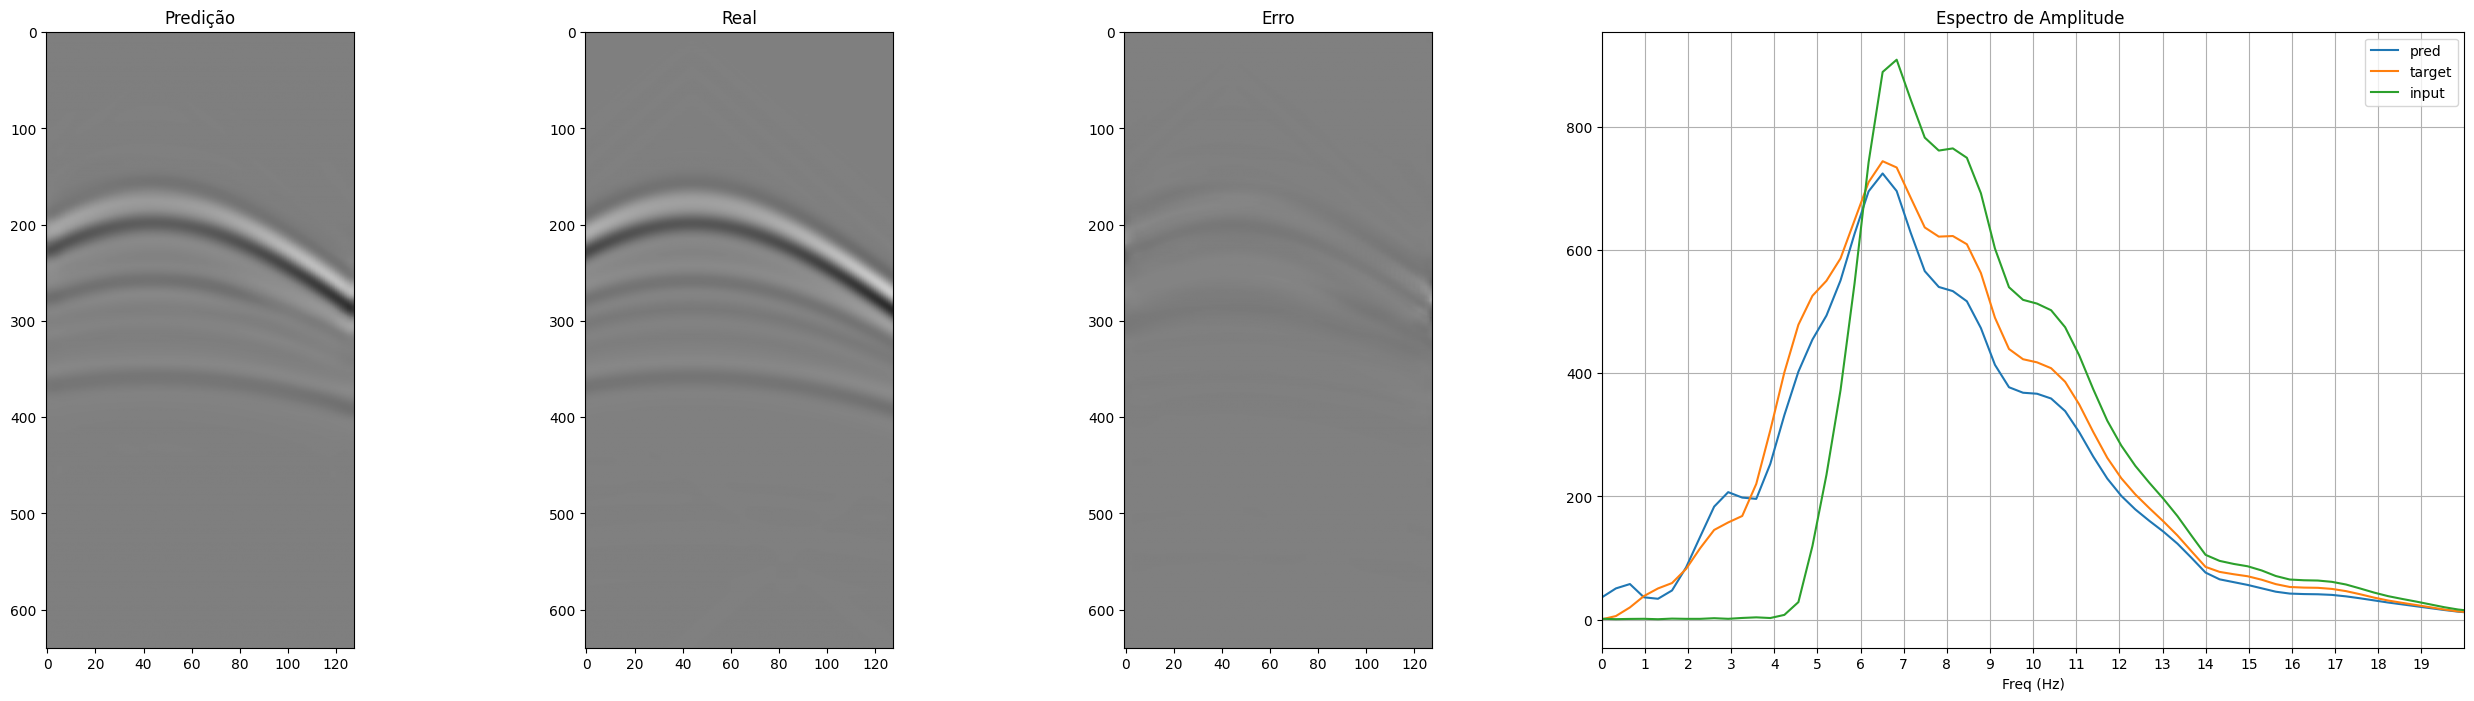

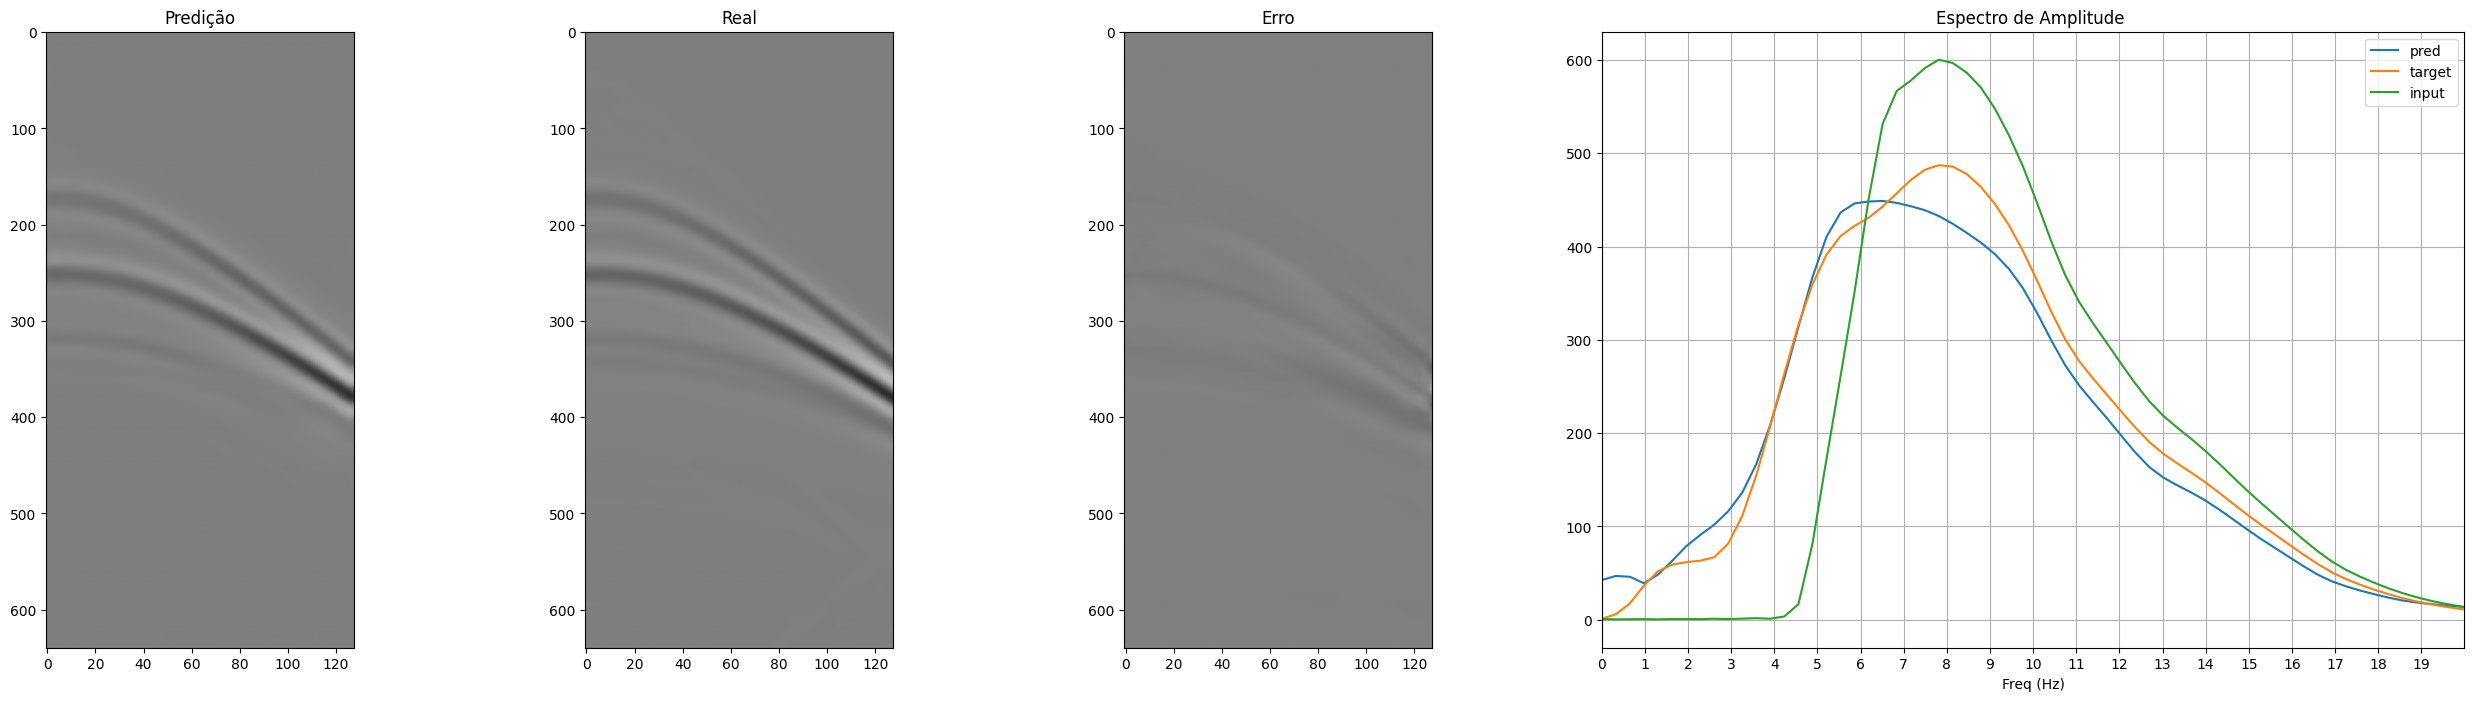

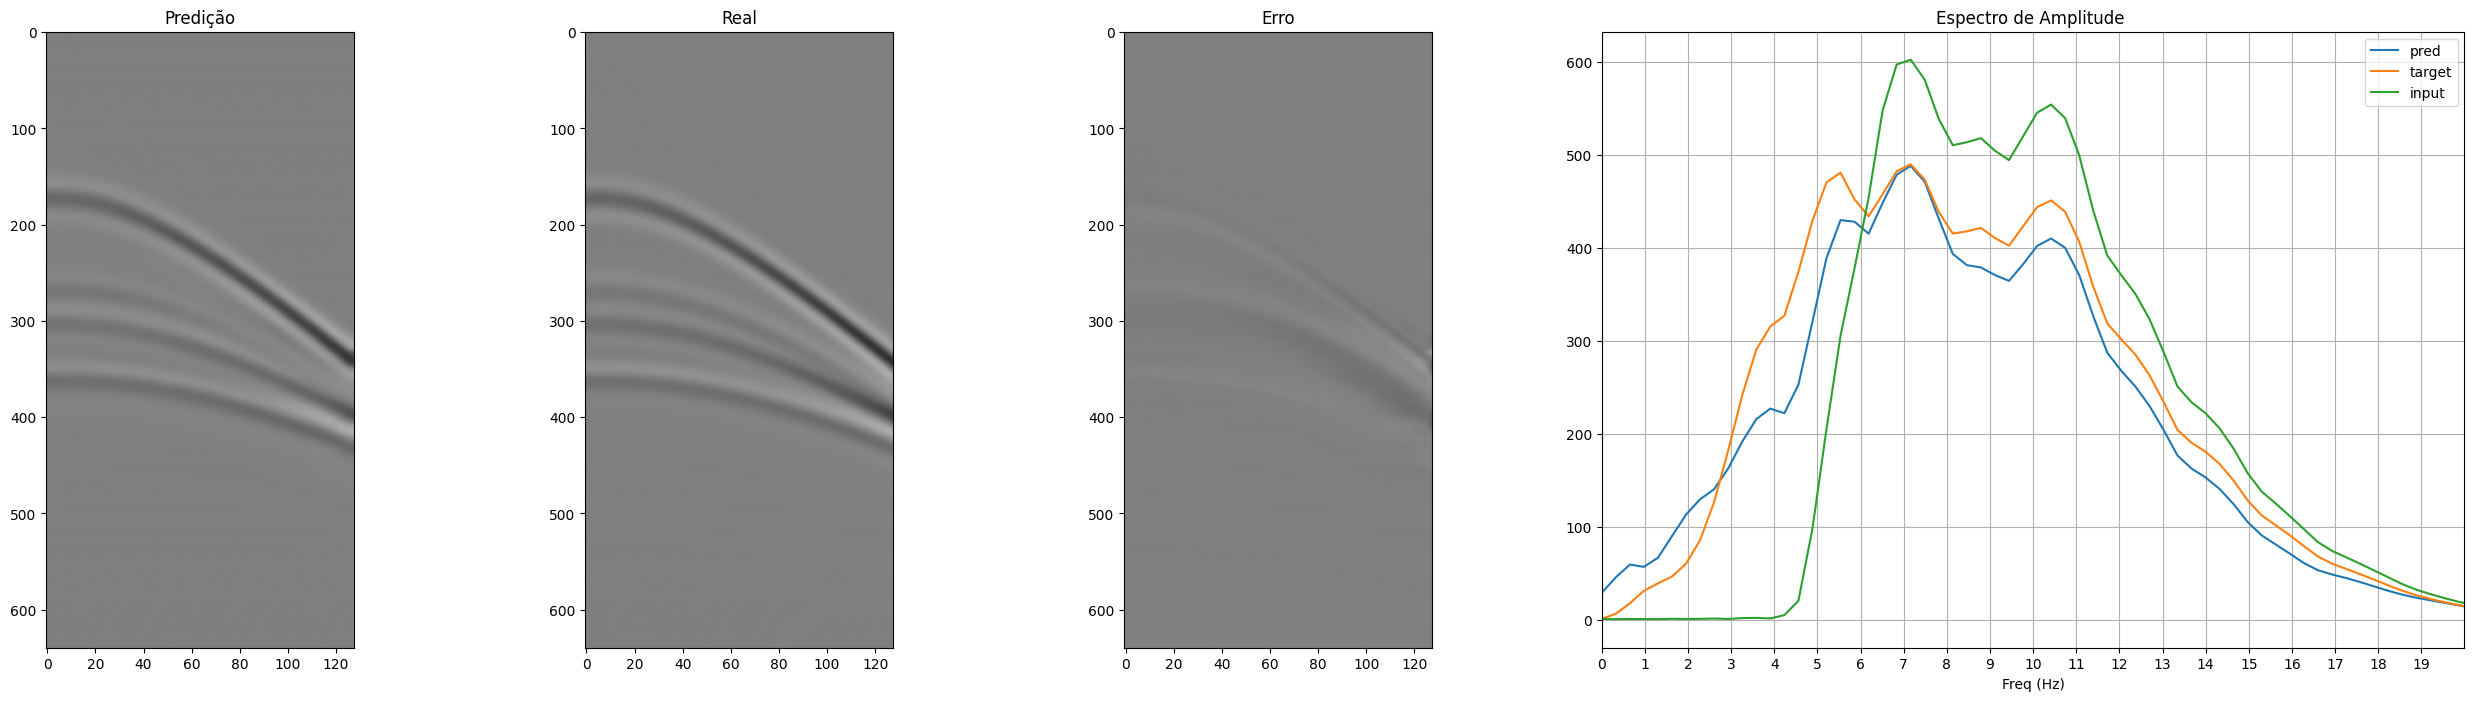

In [31]:
model.load_state_dict(torch.load(modelpath+'.pth'))
model.eval()
aspect=0.4
scale=0.5
pred = model(torch.tensor(x_test, dtype=torch.float32,device=device))
pred_cpu=pred.detach().cpu().numpy()
dt = 0.0030
freq = torch.fft.rfftfreq(1024, dt)
for n_image in range(len(x_test)):
    fig = plt.figure(figsize=(32,8))
    gs = fig.add_gridspec(1, 4,width_ratios=[1, 1, 1, 2])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[0, 3])
    DATA1 = torch.sum(torch.abs(torch.fft.rfft(torch.tensor(pred_cpu[n_image,0,:,:]), 1024,dim=0)),dim=1)
    DATA2 = torch.sum(torch.abs(torch.fft.rfft(torch.tensor(y_test[n_image,0,:,:]), 1024,dim=0)),dim=1)
    DATA3 = torch.sum(torch.abs(torch.fft.rfft(torch.tensor(x_test[n_image,0,:,:]), 1024,dim=0)),dim=1)

    ax1.imshow(pred_cpu[n_image,0,:,:],aspect=aspect,cmap="gray",vmin=-scale,vmax=scale)
    ax1.set_title('Predição')
    ax2.imshow(y_test[n_image,0,:,:],aspect=aspect,cmap="gray",vmin=-scale,vmax=scale)
    ax2.set_title('Real')
    ax3.imshow(y_test[n_image,0,:,:]-pred_cpu[n_image,0,:,:],aspect=aspect, cmap="gray",vmin=-scale,vmax=scale)
    ax3.set_title('Erro')
    ax4.plot(freq, DATA1, label='pred')
    ax4.plot(freq, DATA2, label='target')
    ax4.plot(freq, DATA3, label='input')
    ax4.grid()
    ax4.set_xlim(0,20)
    ax4.set_xlabel('Freq (Hz)')
    ax4.set_xticks(range(0, 20, 1))
    ax4.set_title('Espectro de Amplitude ')
    ax4.legend()
    fig = plt.gcf()
    plt.show()